# What is the most optimal skill to learn for Data Analysts?

#### Methodology
    1. Group skills to determine median salary and likelihood of being in posting
    2. Visualize median salary vs percent skill demand
    3. (optional) Determine if certain technologies are more prevalent

In [17]:
# importing libraries
import pandas as pd 
import ast 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from adjustText import adjust_text

# load data 
dataset = load_dataset('lukebarousse/data_jobs')
df=  dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_da_us = df[(df['job_country'] =='United States') & (df['job_title_short'] =='Data Analyst')].copy()

In [5]:
df_da_us = df_da_us.dropna(subset = 'salary_year_avg')
df_da_us_exploded = df_da_us.explode('job_skills')
df_da_us_exploded[['salary_year_avg','job_skills']].head(10)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
180,90250.0,powerpoint
410,133285.0,sql
410,133285.0,word
410,133285.0,excel
410,133285.0,visio


In [16]:
df_da_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)
df_da_skills = df_da_skills.rename(columns = {'count':'skill_count','median':'median_salary'})
da_job_count = len(df_da_us)
df_da_skills['skill_percent'] = df_da_skills['skill_count'] / da_job_count*100
skill_percent = 5
df_da_skills_high_demand = df_da_skills[df_da_skills['skill_percent']>skill_percent]
df_da_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


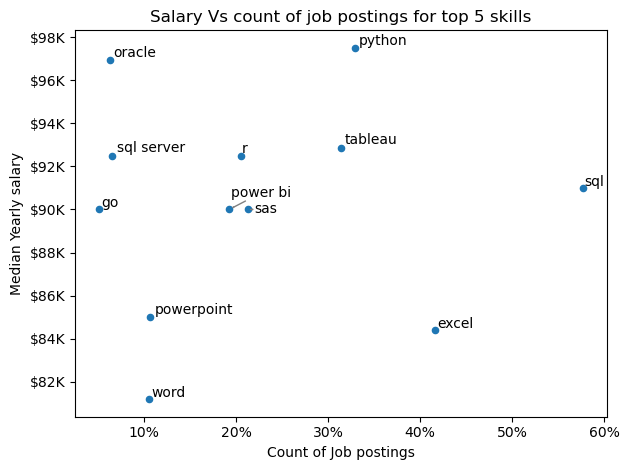

In [22]:
df_da_skills_high_demand.plot(kind='scatter', x = 'skill_percent', y = 'median_salary')

texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i],txt))

# adjust text to avoid overlap
adjust_text(texts, arrowprops= dict(arrowstyle="->", color='gray',lw=1))  

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Count of Job postings')
plt.ylabel('Median Yearly salary')
plt.title(f'Salary Vs count of job postings for top {skill_percent} skills')
plt.tight_layout()
plt.show()

In [25]:
df_technology = df['job_type_skills'].copy()

#remove dupliates
df_technology=df_technology.drop_duplicates()

# remove NaN values
df_technology=df_technology.dropna()

# combine all dictionaries into one
technology_dict ={}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary 
    for key,value in row_dict.items():
        if key in technology_dict:
            technology_dict[key]+=value
        else:
            technology_dict[key] = value
            
# remove duplicates by converting values to set then back to list 
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))
    
technology_dict

{'analyst_tools': ['ssrs',
  'msaccess',
  'excel',
  'sheets',
  'sap',
  'nuix',
  'word',
  'powerpoint',
  'microstrategy',
  'splunk',
  'datarobot',
  'ms access',
  'spreadsheet',
  'visio',
  'cognos',
  'looker',
  'powerbi',
  'power bi',
  'tableau',
  'qlik',
  'spss',
  'dax',
  'ssis',
  'outlook',
  'sas',
  'sharepoint',
  'alteryx',
  'esquisse'],
 'programming': ['lua',
  'vba',
  'perl',
  'f#',
  'css',
  'erlang',
  'assembly',
  'sql',
  'cobol',
  'powershell',
  'crystal',
  't-sql',
  'mongodb',
  'java',
  'kotlin',
  'ocaml',
  'r',
  'javascript',
  'python',
  'bash',
  'apl',
  'scala',
  'nosql',
  'dart',
  'elixir',
  'visualbasic',
  'solidity',
  'fortran',
  'php',
  'lisp',
  'c#',
  'matlab',
  'golang',
  'go',
  'html',
  'c++',
  'sas',
  'visual basic',
  'clojure',
  'swift',
  'vb.net',
  'c',
  'delphi',
  'haskell',
  'groovy',
  'sass',
  'pascal',
  'no-sql',
  'objective-c',
  'typescript',
  'ruby',
  'rust',
  'shell',
  'mongo',
  'ju

In [31]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,ssrs
0,analyst_tools,msaccess
0,analyst_tools,excel
0,analyst_tools,sheets
0,analyst_tools,sap
...,...,...
9,sync,google chat
9,sync,wire
9,sync,zoom
9,sync,twilio


In [38]:
df_plot = df_da_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

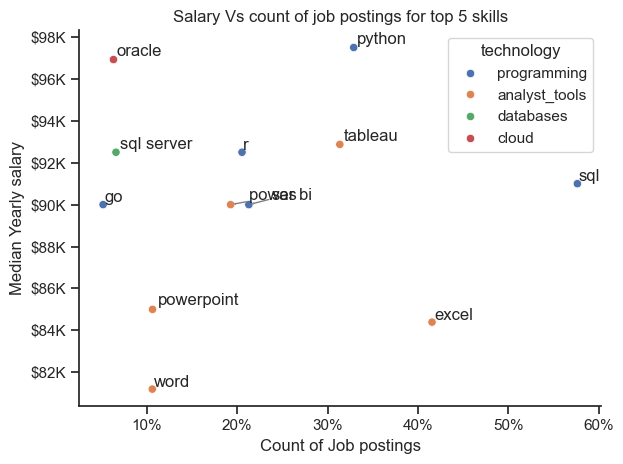

In [50]:
# df_plot.plot(kind='scatter', x = 'skill_percent', y = 'median_salary')

sns.scatterplot(
    data = df_plot,
    x='skill_percent',
    y='median_salary',
    hue = 'technology'
    
)

sns.despine()
sns.set_theme(style='ticks')

# Preapre texts for adjustText
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i],txt))

# adjust text to avoid overlap
adjust_text(texts, arrowprops= dict(arrowstyle="->", color='gray',lw=1))  

ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Count of Job postings')
plt.ylabel('Median Yearly salary')
plt.title(f'Salary Vs count of job postings for top {skill_percent} skills')
plt.tight_layout()
plt.show()